In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load the data
data1 = pd.read_csv('wine-red.csv')
data = data1.drop_duplicates()  

# Separate features and target variable
X = data.drop('quality', axis=1)
y = data['quality']

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the models
rf = RandomForestClassifier(random_state=42)
et = ExtraTreesClassifier(random_state=42)
bagging = BaggingClassifier(base_estimator=DecisionTreeClassifier(), random_state=42)
dt = DecisionTreeClassifier(random_state=42)

# Fit the models on the training data
rf.fit(X_train, y_train)
et.fit(X_train, y_train)
bagging.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Predict on the test set
rf_preds = rf.predict(X_test)
et_preds = et.predict(X_test)
bagging_preds = bagging.predict(X_test)
dt_preds = dt.predict(X_test)

# Calculate and print the accuracy for each model
rf_accuracy = accuracy_score(y_test, rf_preds)
et_accuracy = accuracy_score(y_test, et_preds)
bagging_accuracy = accuracy_score(y_test, bagging_preds)
dt_accuracy = accuracy_score(y_test, dt_preds)

print(f'Random Forest Accuracy: {rf_accuracy:.2f}')
print(f'Extra Trees Accuracy: {et_accuracy:.2f}')
print(f'Bagging Accuracy: {bagging_accuracy:.2f}')
print(f'Decision Tree Accuracy: {dt_accuracy:.2f}')

Random Forest Accuracy: 0.66
Extra Trees Accuracy: 0.69
Bagging Accuracy: 0.64
Decision Tree Accuracy: 0.56


C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


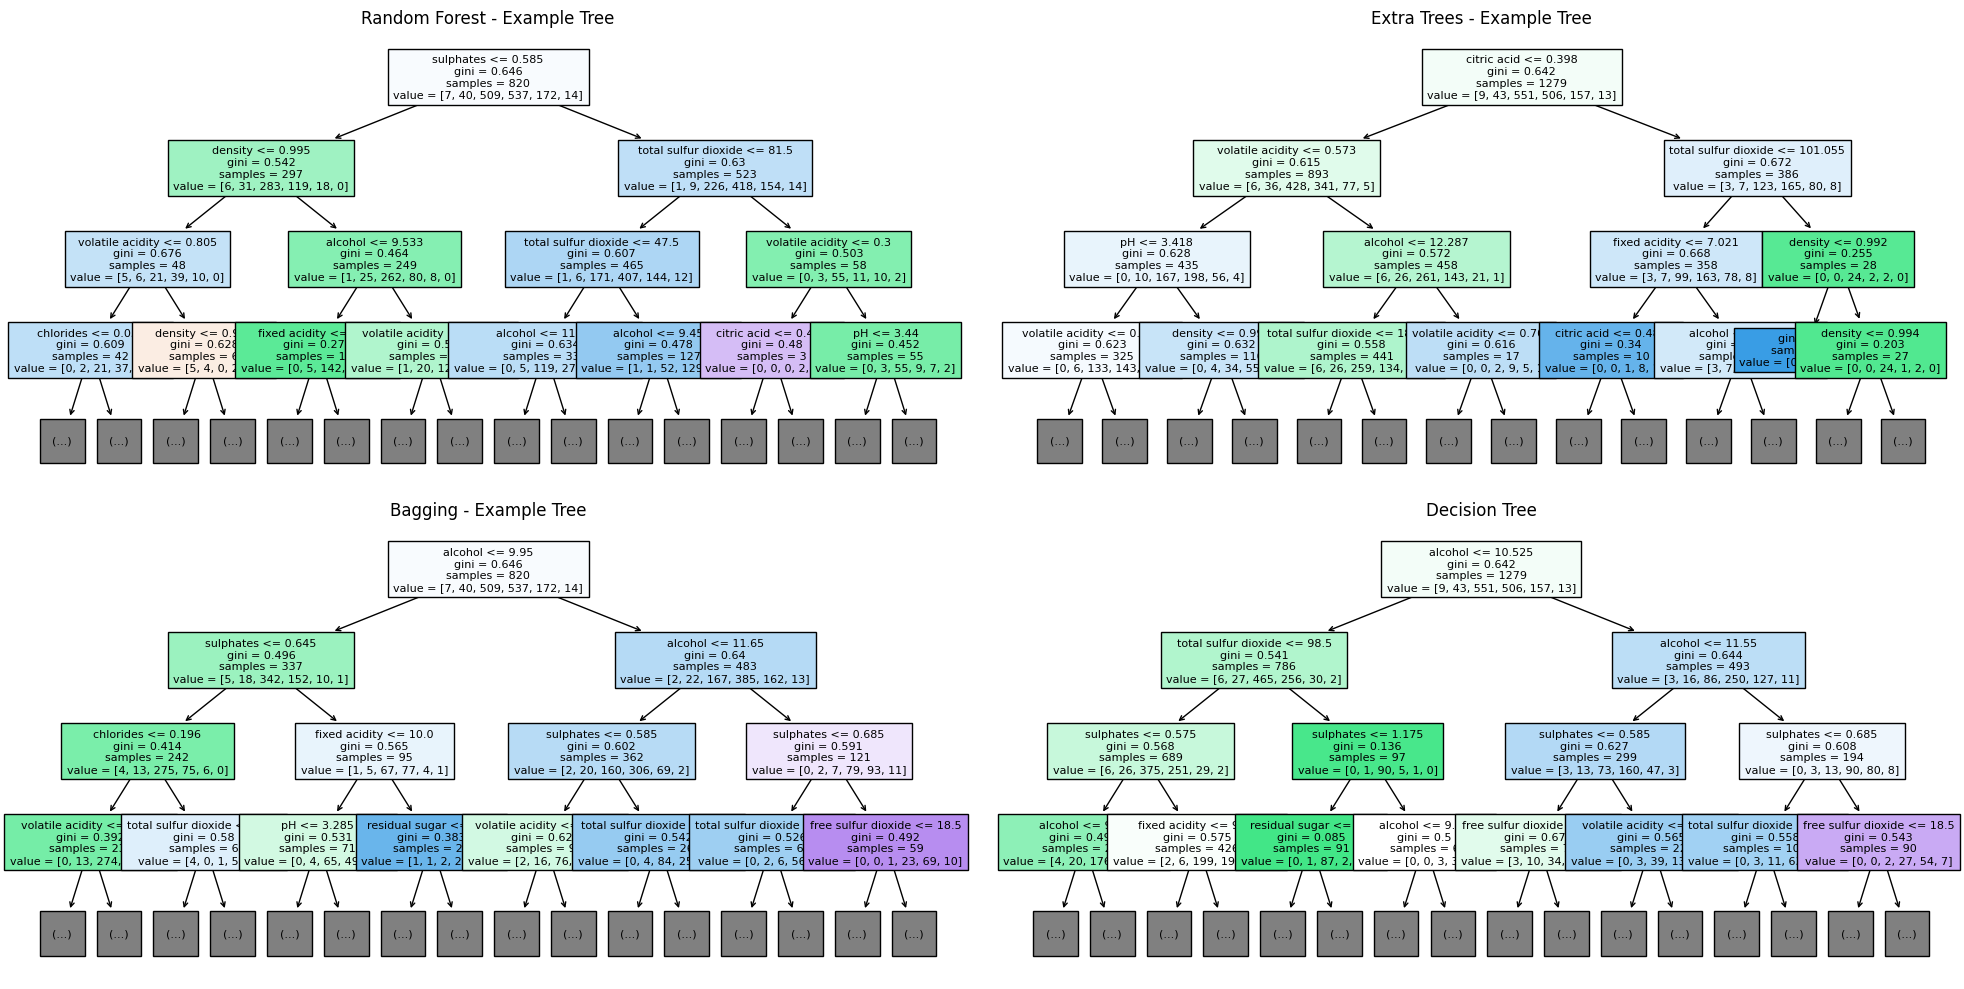

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extract a single tree from each ensemble model
rf_tree = rf.estimators_[0]
et_tree = et.estimators_[0]
bagging_tree = bagging.estimators_[0]

# Initialize the subplot function using number of rows and columns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

# Plot each tree
plot_tree(rf_tree, ax=axes[0, 0], max_depth=3, filled=True, feature_names=X.columns, fontsize=8)
axes[0, 0].set_title('Random Forest - Example Tree')

plot_tree(et_tree, ax=axes[0, 1], max_depth=3, filled=True, feature_names=X.columns, fontsize=8)
axes[0, 1].set_title('Extra Trees - Example Tree')

plot_tree(bagging_tree, ax=axes[1, 0], max_depth=3, filled=True, feature_names=X.columns, fontsize=8)
axes[1, 0].set_title('Bagging - Example Tree')

plot_tree(dt, ax=axes[1, 1], max_depth=3, filled=True, feature_names=X.columns, fontsize=8)
axes[1, 1].set_title('Decision Tree')

plt.tight_layout()
plt.show()